In [1]:
import numpy as np
import pandas as pd
import json
import os
import sqlite3
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

import sys
sys.path.append("../../src")

from Models import *
from ScoreFunction import *
from VideoData import *
from Datapack import *


In [2]:
Models(base_path="../../data/models/")

In [3]:
# collect run data

run_name = "test_5"

base_path = "../../crawl_results/"

conn = sqlite3.connect(os.path.join(base_path, run_name, "videos.db"))
cursor = conn.cursor()

cursor.execute("SELECT * FROM videos")
videos = cursor.fetchall()

cursor.execute("SELECT * FROM recommendations ORDER BY idx")
recommendations_list = cursor.fetchall()

conn.close()


In [4]:
# Process data


# root video
root_id = recommendations_list[0][1]


# Build recommendations
recommendations:dict[str, list[str]] = {}
child_seen = set([root_id])
for idx, parent_id, video_id in recommendations_list:
    if video_id in child_seen:
        continue
    child_seen.add(video_id)
    if parent_id not in recommendations:
        recommendations[parent_id] = []
    recommendations[parent_id].append(video_id)
    

# Build child to parent lookup
parents_lookup:dict[str, str] = {}
for parent, children in recommendations.items():
    for child in children:
        parents_lookup[child] = parent


# Bundle video data  
all_videos:dict[str, VideoData] = {}
vid = VideoData(video_id=root_id, title="", channel="", views=0, length=0, uploaded=0)
vid.reset_additional_data()
all_videos[root_id] = vid
for id, title, channel, views, length, uploaded in videos:
    vid = VideoData(video_id=id, title=title, channel=channel, views=views, length=length, uploaded=uploaded)
    vid.reset_additional_data()
    all_videos[id] = vid
    

# calculate tree depths
stack = [root_id]
while len(stack) > 0:
    current_id = stack.pop()
    current_video = all_videos[current_id]
    if current_id in recommendations:
        for child_id in recommendations[current_id]:
            child_video:VideoData = all_videos[child_id]
            child_video.process(current_video)
            stack.append(child_id)


# create embeddings for all videos
batch_size = 64
all_video_ids = list(all_videos.keys())
for i in tqdm(range(0, len(all_videos), batch_size), desc="Embedding videos"):
    ids = all_video_ids[i:i+batch_size]
    titles = [all_videos[id].title for id in ids]
    embs = Models().embed_text(titles)
    for j, id in enumerate(ids):
        all_videos[id].embedding = embs[j].reshape(1, -1)


Embedding videos:   0%|          | 0/352 [00:00<?, ?it/s]d:\Python\Python310\lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Embedding videos: 100%|██████████| 352/352 [00:39<00:00,  8.80it/s]


In [5]:
# score videos

sf = SmallVideoScoreFunction()
for parent_id, child_ids in tqdm(recommendations.items(), desc="Scoring videos"):
    parent_video = all_videos[parent_id]
    child_videos = [all_videos[child_id] for child_id in child_ids]
    scored_children = sf.score(parent_video, child_videos, inplace=True)
    for vid in scored_children:
        all_videos[vid.video_id] = vid

Scoring videos: 100%|██████████| 4467/4467 [00:08<00:00, 515.66it/s]


---
# Analyse

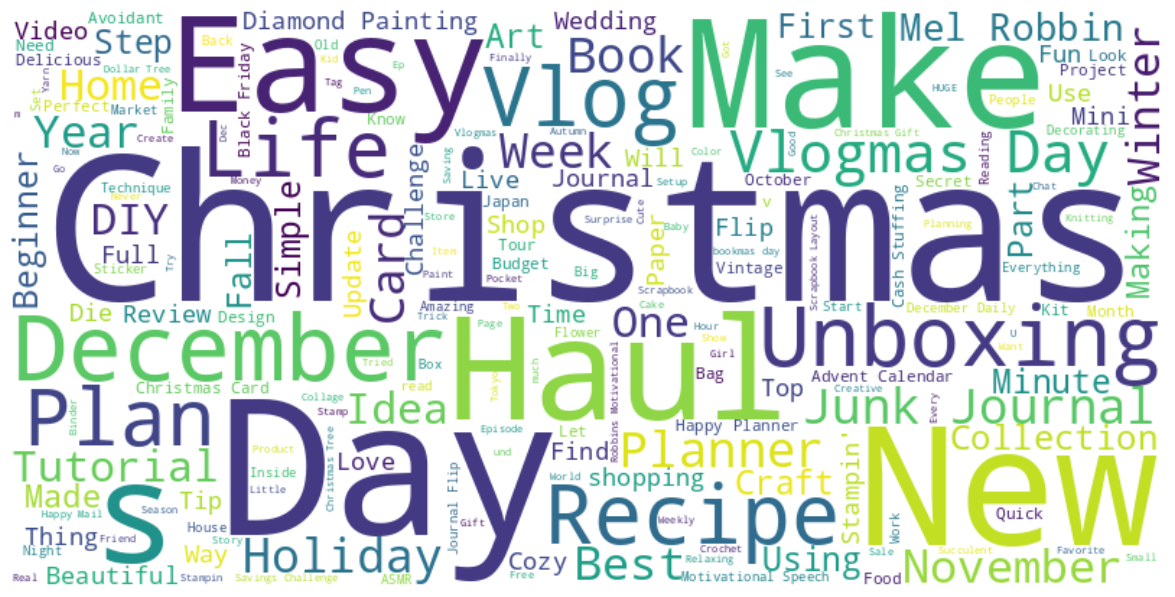

Top words in titles:
Christmas: 1.0000
Day: 0.8696
New: 0.6597
Make: 0.5452
Haul: 0.4858
s: 0.4732
Easy: 0.4281
December: 0.4139
Unboxing: 0.3888
Recipe: 0.3696
Vlog: 0.3662
Life: 0.3370
Plan: 0.3328
Vlogmas Day: 0.3328
Junk Journal: 0.3236
Planner: 0.3169
Book: 0.3169
Holiday: 0.3043
Week: 0.3035
Card: 0.3010
Best: 0.2776
November: 0.2759
Winter: 0.2559
Year: 0.2542
One: 0.2450


In [6]:
# wordcloud of titles
from wordcloud import WordCloud

text = " ".join([vid.title for vid in all_videos.values()])
# text = " ".join([all_videos[id].title for id in recommendations.keys()])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

%matplotlib inline
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# print top words
word_freq = wordcloud.words_
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
print("Top words in titles:")
for word, freq in sorted_words[:25]:
    print(f"{word}: {freq:.4f}")


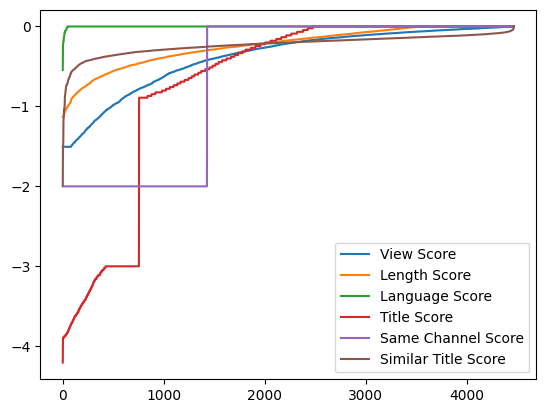

In [8]:
%matplotlib inline

def clip(a):
    a[a <= MIN_SCORE] = np.min(a[a > MIN_SCORE]) - 10


def add_plot(ax, a, label=""):
    clip(a)
    a.sort()
    ax.plot(a, label=label)

# vids = all_videos.values()
vids = [all_videos[id] for id in recommendations.keys()]

ax = plt.gca()
# add_plot(ax, np.array([vid.score.localized_score for vid in vids]), label="Localized Score")
# add_plot(ax, np.array([vid.score.absolute_score for vid in vids]), label="Absolute Score")
add_plot(ax, np.array([vid.score.view_score for vid in vids]), label="View Score")
add_plot(ax, np.array([vid.score.length_score for vid in vids]), label="Length Score")
add_plot(ax, np.array([vid.score.language_score for vid in vids]), label="Language Score")
add_plot(ax, np.array([vid.score.title_score for vid in vids]), label="Title Score")
add_plot(ax, np.array([vid.score.same_channel_score for vid in vids]), label="Same Channel Score")
add_plot(ax, np.array([vid.score.similar_title_score for vid in vids]), label="Similar Title Score")
plt.legend()
plt.show()

In [10]:
# save titles ordered by language score

def get_title_language_score(title:str):
 
    def ascii_ratio(text:str):
        ascii_count = sum(1 for c in text if c.isascii() and not c.isspace())
        total_count = sum(1 for c in text if not c.isspace())
        return ascii_count / total_count if total_count > 0 else 0.0
    
    lang, prob = Models().predict_language(title.lower())

    if lang not in ["de", "en"]: # if not target language
        if prob > 0.5: # if high confidence
            return lang, prob, MIN_SCORE
        else: # maybe mix of multiple languages
            r = ascii_ratio(title)
            if r < 0.6:
                return lang, prob, MIN_SCORE
            return lang, r, as_log((r-0.6)/0.4)
    return lang, prob, MAX_SCORE+prob

titles = [(vid.title, get_title_language_score(vid.title), vid.video_id) for vid in all_videos.values()]
titles.sort(key=lambda x: x[1][2], reverse=True)
# titles.sort(key=lambda x: len(x[0]), reverse=True)
with open("language_score_titles.txt", "w", encoding="utf-8") as f:
    for title, pred, video_id in titles:
        lang, conf, score = pred
        pred = f"({lang} | {conf:.4f} | {score:.4f})"
        f.write(f"{pred}\t{title} [{video_id}]\n")

In [11]:
score_df = pd.DataFrame([{
    "view_score": vid.score.view_score,
    "length_score": vid.score.length_score,
    "language_score": vid.score.language_score,
    "title_score": vid.score.title_score,
    "similar_title_score": vid.score.similar_title_score,
    "same_channel_score": vid.score.same_channel_score,
    "depth_score": vid.score.depth_score,
    "normal_score": vid.score.normal_score,
    "absolute_score": vid.score.absolute_score,
    "total_score": vid.score.total_score,
} for vid in all_videos.values()])
# score_df = score_df.clip(lower=-100)
# score_df = score_df[score_df["total_score"] > -100]
score_df.describe()

,view_score,length_score,language_score,title_score,similar_title_score,same_channel_score,depth_score,normal_score,absolute_score,total_score
count,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000,22469.000000
mean,-480.960474,-43.740325,-28.173373,-0.680204,-0.251012,-0.761049,-4.074697,0.001543,-512.648570,-515.484119
std,499.439241,203.889430,165.467907,1.129517,0.357491,0.971053,0.963782,0.010001,499.153494,496.250181
min,-1000.000000,-1000.000000,-1000.000000,-4.202925,-6.000000,-2.000000,-6.321630,0.000000,-1000.000000,-1000.000000
25%,-1000.000000,-0.444772,0.000000,-0.712845,-0.273973,-2.000000,-4.816480,0.000000,-1000.000000,-1000.000000
50%,-1.411831,-0.220881,0.000000,-0.155935,-0.190438,0.000000,-4.214420,0.000000,-1000.000000,-1000.000000
75%,-0.213731,-0.062840,0.000000,0.000000,-0.134515,0.000000,-3.612360,0.000853,-0.982863,-7.067109
max,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


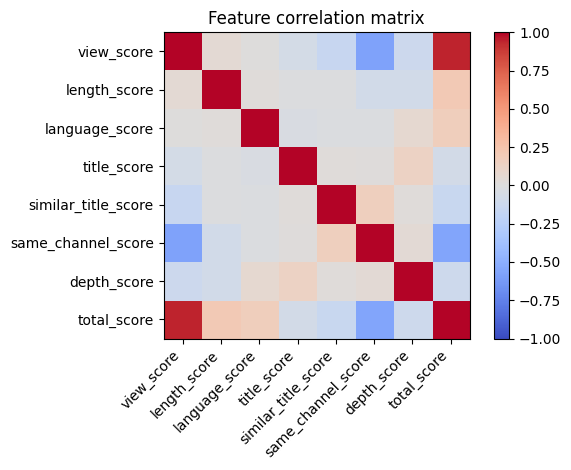

In [12]:
%matplotlib inline
corr = score_df.drop(columns=["absolute_score", "normal_score"]).corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [13]:
%matplotlib qt
score_df.plot.scatter(x="same_channel_score", y="total_score")
plt.title("Same Channel Score vs Total Score")
plt.show()

In [14]:
%matplotlib qt
score_df.hist(bins=50, figsize=(12,8))
plt.suptitle("Score Feature Distributions")
plt.tight_layout()
plt.show()

In [18]:
random_id = random.choice(list(all_videos.keys()))
print(random_id)
print(all_videos[random_id].title)
print("views", all_videos[random_id].views)
print("length", all_videos[random_id].length)
print("channel", all_videos[random_id].channel)
print("uploaded", all_videos[random_id].uploaded)
print("tree_depth", all_videos[random_id].tree_depth)
s = all_videos[random_id].score
print(s)

qrqtRgq5ODY
How to Make Your First Quilt: Easy Steps for Beginners
views 153
length 4918
channel Exshaw Quilts
uploaded 1765641316
tree_depth 13
Score(view: -0.23, len: -1000.0, lang: 0.0, title: 0.0, depth: -3.913, channel: -2.0, sim_title: -0.155, total: -1000.0)


In [ ]:

pickset_scorecompositions = []
depth_data = []

dp = Datapack()
squash_interval = 10_000
for idx, (parent_id, child_ids) in tqdm(enumerate(recommendations.items(), start=1), total=len(recommendations), desc="Replay crawl"):
    parent_video = all_videos[parent_id]
    child_videos = [all_videos[child_id] for child_id in child_ids]
        
    dp.remove_video(parent_id) # pick parent video
    dp.add_videos(child_videos) # add recommended videos
    
    if idx % squash_interval == 0:
        dp.squash(reset_after=False)
        
        
    # ===== Read datapack here for analysis =====
    vids = [vid for vid in dp.pickset if vid.score.total_score > MIN_SCORE]

    pickset_size = len(dp.pickset)
    num_bad_vids = len(dp.pickset) - len(vids)
    mean_total_score = np.mean([vid.score.total_score for vid in vids])
    mean_view_score = np.mean([vid.score.view_score for vid in vids])
    mean_length_score = np.mean([vid.score.length_score for vid in vids])
    mean_language_score = np.mean([vid.score.language_score for vid in vids])
    mean_title_score = np.mean([vid.score.title_score for vid in vids])
    mean_depth_score = np.mean([vid.score.depth_score for vid in vids])
    mean_similar_title_score = np.mean([vid.score.similar_title_score for vid in vids])
    mean_same_channel_score = np.mean([vid.score.same_channel_score for vid in vids])

    pickset_scorecompositions.append({
        "pickset_size": pickset_size,
        "num_bad_vids": num_bad_vids,
        "mean_total_score": mean_total_score,
        "mean_view_score": mean_view_score,
        "mean_length_score": mean_length_score,
        "mean_language_score": mean_language_score,
        "mean_title_score": mean_title_score,
        "mean_depth_score": mean_depth_score,
        "mean_similar_title_score": mean_similar_title_score,
        "mean_same_channel_score": mean_same_channel_score,
    })
    
    depths = np.array([vid.tree_depth for vid in dp.pickset])
    # depths -= np.min(depths)
    depth_data.append({
        "index": idx,
        "mean_depth": np.mean(depths),
        "max_depth": np.max(depths),
        "min_depth": np.min(depths),
        "std_depth": np.std(depths),
        "1st_percentile_depth": np.percentile(depths, 1),
        "25th_percentile_depth": np.percentile(depths, 25),
        "50th_percentile_depth": np.percentile(depths, 50),
        "75th_percentile_depth": np.percentile(depths, 75),
    })


pickset_df = pd.DataFrame(pickset_scorecompositions)
pickset_df.reset_index(inplace=True)

depth_df = pd.DataFrame(depth_data)
depth_df.reset_index(inplace=True)

Replay crawl: 100%|██████████| 4467/4467 [00:28<00:00, 156.76it/s]


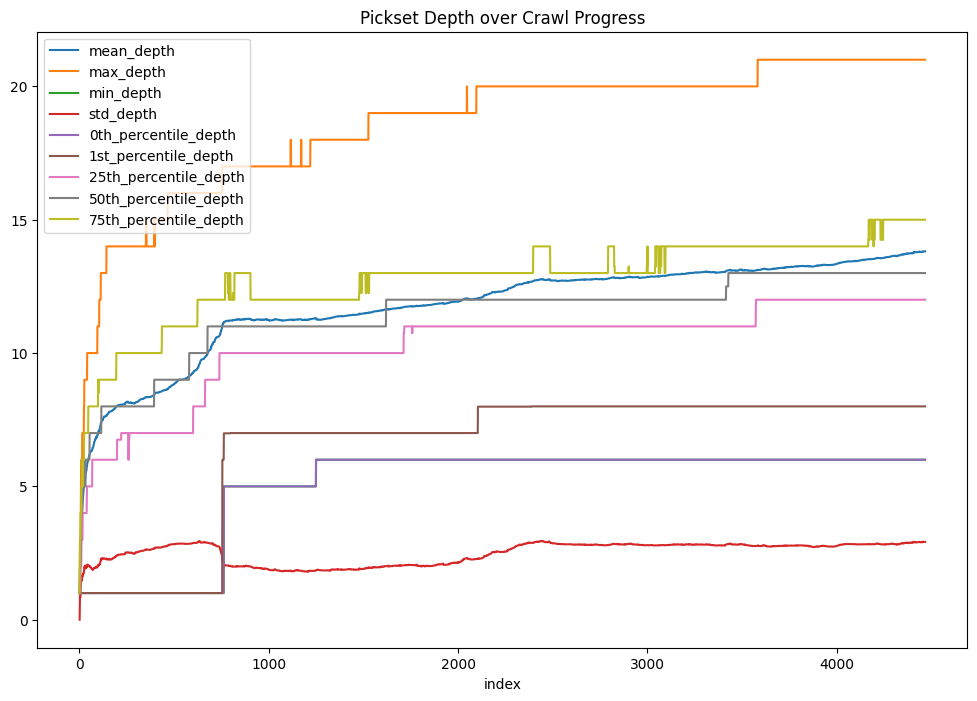

In [ ]:
# depth analysis

%matplotlib inline
depth_df.plot(x="index", y=["mean_depth", "max_depth", "min_depth", "std_depth", "1st_percentile_depth", 
                            "25th_percentile_depth", "50th_percentile_depth", "75th_percentile_depth"], figsize=(12,8))
plt.title("Pickset Depth over Crawl Progress")
plt.show()

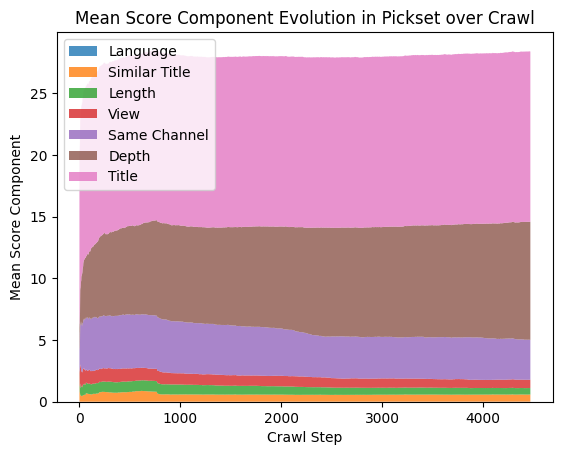

In [15]:
# score component plot
%matplotlib inline

order = ["mean_view_score", 
         "mean_length_score",
         "mean_language_score",
         "mean_title_score",
         "mean_depth_score", 
         "mean_similar_title_score", 
         "mean_same_channel_score"]
order = sorted(order, key=lambda col: pickset_df[col].mean(), reverse=True)


plt.stackplot(pickset_df["index"], 
            [-pickset_df[col] for col in order],
            labels=[col.replace("mean_", "").replace("_score", "").replace("_", " ").title() for col in order],
            alpha=0.8)
plt.legend(loc="upper left")
plt.title("Mean Score Component Evolution in Pickset over Crawl")
plt.xlabel("Crawl Step")
plt.ylabel("Mean Score Component")


plt.show()

mrDVp0SU_hs
Putting All The Money Back | New Savings Challenge | Canadian Cash Stuffer 
views 121
length 1801
channel HelloHappyBudgets
uploaded 1764872656
tree_depth 12
Score(view: -0.182, len: -0.452, lang: 0.0, title: -0.334, depth: -3.612, channel: 0.0, sim_title: -0.298, total: -4.879)


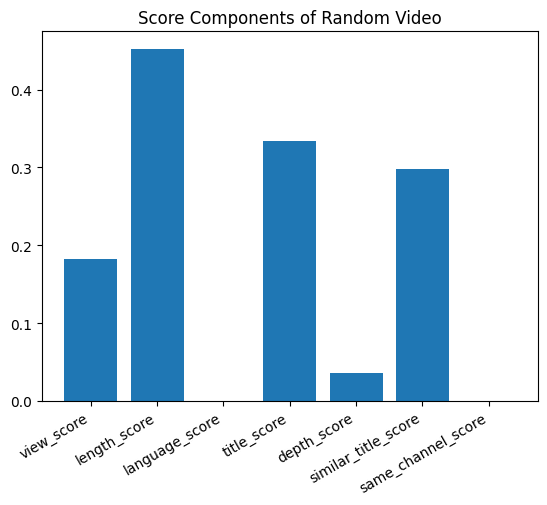

In [24]:
# scores of random video
random_id = random.choice(list(all_videos.keys()))
random_id = random.choice(list(recommendations.keys()))
# random_id = "yG3eIrLUC9Y"
print(random_id)
vid = all_videos[random_id]
s = vid.score
print(all_videos[random_id].title)
print("views", all_videos[random_id].views)
print("length", all_videos[random_id].length)
print("channel", all_videos[random_id].channel)
print("uploaded", all_videos[random_id].uploaded)
print("tree_depth", all_videos[random_id].tree_depth)
print(s)

scores = [("view_score", s.view_score),
          ("length_score", s.length_score),
          ("language_score", s.language_score),
          ("title_score", s.title_score),
          ("depth_score", s.depth_score/100),
          ("similar_title_score", s.similar_title_score),
          ("same_channel_score", s.same_channel_score)]

%matplotlib inline
plt.bar([x[0] for x in scores], [min(-x[1], 100) for x in scores])
# plt.bar([x[0] for x in scores], [np.exp(x[1]) for x in scores], alpha=0.6)

plt.xticks(rotation=30, ha="right")
# plt.yscale("log")
# plt.ylim(0, 1.05)
plt.title("Score Components of Random Video")
plt.show()

In [22]:
# build webpage

def format_uploaded(timestamp):
    if timestamp == 0:
        return "Unknown published date"
    diff = int(time.time() - timestamp)
    if diff < 60:
        return f"{diff} seconds ago"
    elif diff < 3600:
        return f"{diff // 60} minutes ago"
    elif diff < 86400:
        return f"{diff // 3600} hours ago"
    elif diff < 604800:
        return f"{diff // 86400} days ago"
    elif diff < 2592000:
        return f"{diff // 604800} weeks ago"
    elif diff < 31536000:
        return f"{diff // 2592000} months ago"
    else:
        return f"{diff // 31536000} years ago"

video_data = []

def add_video(id):
    global video_data
    if id not in all_videos:
        return
    
    video = all_videos[id]
    video_data.append({
        "idx": len(video_data),
        "id": id,
        "title": video.title,
        "views": video.views,
        "length": video.length,	
        "channel": video.channel,
        "uploaded_ts": video.uploaded or 0,
        "uploaded": format_uploaded(video.uploaded or 0),
        "total_score": np.exp(video.score.localized_score),
        "in_history": id in recommendations,
    })
    
for parent_id, children in recommendations.items():
    add_video(parent_id)
    for child_id in children:
        if child_id not in recommendations:
            add_video(child_id)





with open("webpage_template.html", "r", encoding="utf-8") as f:
    webpage_template = f.read()

# Inject video JSON data into the template
video_json = json.dumps(video_data)
html_final = webpage_template.replace("%VIDEO_DATA%", video_json)

output_file="youtube_gallery.html"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(html_final)

